In [1]:
import math
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import os

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'Times New Roman'


In [2]:
# 配置与路径
N_GROUPS = 5
INCIDENCE_CSV = r"D:\app\OneDrive\Desktop\04 百日咳新策略\data\4group20-2025.csv"
POP_CSV = r"D:\app\OneDrive\Desktop\04 百日咳新策略\data\population_age_groups20.csv"
EXCEL_BD = r"D:\app\OneDrive\Desktop\04 百日咳新策略\data\chushengsiwang.xlsx"
years = list(range(2010, 2025))        # 2010-2024，对应你的 Excel
n_months_total = len(years) * 12      
OUT_DIR = Path("fit_segments")  # 输出目录
GROUP_LABELS = [f"G{i}" for i in range(1, N_GROUPS + 1)]

# 分段配置
SEGMENT_LENGTH = 96    # 每段长度（月）
SEGMENT_OVERLAP = 0    # 段间重叠（月，设为 0 表示不重叠）

# 模型参数（按月）
OMEGA = 30 / 10   # E->I
GAMMA = 30 / 35   # I->R
EPS1  = 1.0 / 60.0  # V->S
EPS2  = 1.0 / 120.0  # R->S
ALPHA = np.array([1/6.0, 1/18.0, 1/48.0, 1/48.0, 1/120.0])  # aging rates
PHO   = np.array([0.99, 0.73, 0.0, 0.0, 0.0])
V_EFF = np.array([0.90, 0.90, 0.90, 0.90, 0.90])

# 季节性（默认；可按段覆盖）
SEASON_AMPL = 0.20   # 全局默认振幅（例如 0.10 表示 ±10%）
SEASON_PHASE = 0  # 全局默认相位（年为单位，0 表示 1 月为基线）

# 可选：为每一段定义振幅（长度应与 segments 对齐）。
# 留空或设为 None 使用全局默认。
SEASON_AMPL_PER_SEG = None  # 例如: [0.20, 0.15, 0.25, 0.10]

# 基线 beta 矩阵（作为初始猜测）
BETA_BASE = np.array([
    [0.70, 0.50, 0.55, 0.10, 0.12],
    [0.40, 0.35, 0.20, 0.15, 0.18],
    [0.25, 0.20, 0.30, 0.18, 0.20],
    [0.20, 0.15, 0.18, 0.28, 0.26],
    [0.18, 0.14, 0.16, 0.24, 0.30]
], dtype=float)


In [3]:
POP_COLUMN_MAP = {
    "0_6m": "G1",
    "6m_2y": "G2",
    "2_6y": "G3",
    "6_10y": "G4",
    "10_20y": "G5",
}


def load_incidence(csv_path: str) -> pd.DataFrame:
    """读取月度发病数：要求包含 group1..groupN 列；自动忽略时间列。"""
    df = pd.read_csv(csv_path)
    df.columns = [c.strip().lower() for c in df.columns]
    for time_col in ("time", "t", "month"):
        if time_col in df.columns:
            df = df.drop(columns=[time_col])
    group_cols = [f"group{i}" for i in range(1, N_GROUPS + 1)]
    missing = [c for c in group_cols if c not in df.columns]
    if missing:
        raise ValueError(f"发病数据缺少列: {missing}")
    sub = df[group_cols].copy()
    for c in sub.columns:
        if sub[c].dtype == object:
            sub[c] = sub[c].astype(str).str.replace(",", "").str.replace(" ", "")
        sub[c] = pd.to_numeric(sub[c], errors='coerce').fillna(0.0)
    sub.columns = GROUP_LABELS
    return sub


def load_population(csv_path: str, n_months: int) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df = df.sort_values("year")
    rename_map = {src: dst for src, dst in POP_COLUMN_MAP.items() if src in df.columns}
    df = df.rename(columns=rename_map)
    missing = [g for g in GROUP_LABELS if g not in df.columns]
    if missing:
        raise ValueError(f"人口数据缺少列: {missing}")
    df[GROUP_LABELS] = df[GROUP_LABELS] * 10000.0

    monthly_rows = []
    for _, row in df.iterrows():
        monthly_rows.extend([row[GROUP_LABELS].values] * 12)

    pop_monthly = np.vstack(monthly_rows)
    if pop_monthly.shape[0] < n_months:
        pad = np.tile(pop_monthly[-1], (n_months - pop_monthly.shape[0], 1))
        pop_monthly = np.vstack([pop_monthly, pad])
    pop_monthly = pop_monthly[:n_months]
    return pd.DataFrame(pop_monthly, columns=GROUP_LABELS)


In [4]:
def derive_births_and_deaths(xlsx_path: str, years: list, n_months: int, sheet_name: str = "Sheet3"):
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name)
    df.columns = [c.strip().lower() for c in df.columns]
    birth_candidates = [c for c in df.columns if "birth" in c]
    birth_col = birth_candidates[0] if birth_candidates else "birth"
    death_cols = sorted([c for c in df.columns if c.startswith("death")])
    if len(death_cols) < N_GROUPS:
        raise ValueError(f"死亡率列数量不足，期望 {N_GROUPS}，实际 {len(death_cols)}")
    death_cols = death_cols[:N_GROUPS]
    df = df[["year", birth_col] + death_cols].copy()
    df = df.sort_values("year").reset_index(drop=True)
    births_monthly = []
    dr_monthly = []
    for _, row in df.iterrows():
        monthly_birth = row[birth_col] * 10000 / 12.0
        monthly_dr = np.array([row[c] / 12.0 for c in death_cols], dtype=float)
        births_monthly.extend([monthly_birth] * 12)
        dr_monthly.extend([monthly_dr] * 12)
    births_monthly = np.array(births_monthly[:n_months])
    dr_monthly = np.array(dr_monthly[:n_months])
    return births_monthly, dr_monthly


def vseir_rhs(t, y, params):
    y = np.maximum(y, 0.0)

    beta_flat = params["beta_flat"]
    births_series = params["births_monthly"]
    dr_series = params["dr_monthly"]
    season_ampl = params.get("season_ampl", SEASON_AMPL)
    season_phase = params.get("season_phase", SEASON_PHASE)
    n = params.get("n_groups", N_GROUPS)
    beta_mat = np.asarray(beta_flat).reshape(n, n)

    idx = int(np.floor(t))
    idx = np.clip(idx, 0, len(births_series) - 1)
    births_inflow = births_series[idx]
    dr = np.asarray(dr_series[idx], dtype=float)

    V = y[0:n]
    S = y[n:2*n]
    E = y[2*n:3*n]
    I = y[3*n:4*n]
    R = y[4*n:5*n]
    N = V + S + E + I + R
    infectious_frac = np.divide(I, N, out=np.zeros_like(I), where=N > 0)
    lam = beta_mat @ infectious_frac

    season_factor = 1.2 + season_ampl * np.sin(2.0 * np.pi * (t/12.0 + season_phase))
    season_factor = np.maximum(season_factor, 0.01)
    lam = np.maximum(lam * season_factor, 0.0)

    alpha_vec = ALPHA[:n]
    dS = EPS2 * R + EPS1 * V - lam * S - (dr + alpha_vec) * S
    dE = lam * S - OMEGA * E - (dr + alpha_vec) * E
    dI = OMEGA * E - GAMMA * I - (dr + alpha_vec) * I
    dR = GAMMA * I - EPS2 * R - (dr + alpha_vec) * R
    dV = -EPS1 * V - (dr + alpha_vec) * V
    dS[0] += births_inflow

    for g in range(1, n):
        gm1 = g - 1
        ag_s_out = ALPHA[gm1] * S[gm1]
        to_V = PHO[gm1] * V_EFF[gm1] * ag_s_out
        to_S = (1.0 - PHO[gm1] * V_EFF[gm1]) * ag_s_out
        dV[g] += to_V + ALPHA[gm1] * V[gm1]
        dS[g] += to_S
        dE[g] += ALPHA[gm1] * E[gm1]
        dI[g] += ALPHA[gm1] * I[gm1]
        dR[g] += ALPHA[gm1] * R[gm1]

    return np.concatenate([dV, dS, dE, dI, dR])


def simulate(times, y0, params):
    y0 = np.maximum(y0, 0.0)

    def rhs_with_clipping(t, y):
        dy = vseir_rhs(t, y, params)
        y_clipped = np.maximum(y, 0.0)
        for i in range(len(y)):
            if y_clipped[i] < 1e-10 and dy[i] < 0:
                dy[i] = max(dy[i], -y_clipped[i] * 0.9)
        return dy

    sol = solve_ivp(rhs_with_clipping, (times[0], times[-1]), y0,
                    t_eval=times, method='RK45', vectorized=False, rtol=1e-6, atol=1e-9)

    if not sol.success:
        raise RuntimeError(sol.message)

    Y = np.maximum(sol.y, 0.0)
    if np.any(Y < -1e-10):
        print(f"警告：检测到负的状态变量，已强制为非负。最小值: {np.min(Y)}")
        Y = np.maximum(Y, 0.0)

    return Y


def model_curve_from_state(state_y):
    n = N_GROUPS
    E = np.maximum(state_y[2*n:3*n, :], 0.0)
    return OMEGA * E


def fit_beta_full(times, y0, incidence_obs, births_series, dr_series,
                  weight_power: float = 1.5, weight_eps: float = 10.0,
                  season_ampl: float = None, season_phase: float = None,
                  beta_init: np.ndarray = None,
                  enable_reporting: bool = True,
                  rho_init: np.ndarray = None,
                  rho_prev: np.ndarray = None,
                  rho_smooth_lambda: float = 0.0,
                  rho_bounds=(0.01, 1.0),
                  rho_prior_alpha: float = 6.0,
                  rho_prior_beta: float = 2.0,
                  rho_prior_weight: float = 1.0):

    n = N_GROUPS
    beta_dim = n * n

    if beta_init is not None:
        x0_beta = np.maximum(beta_init.flatten(), 0.05)
    else:
        x0_beta = np.maximum(BETA_BASE.flatten(), 0.05)

    lb_beta = np.full(beta_dim, 1e-7)
    ub_beta = np.full(beta_dim, 2.0)

    if enable_reporting:
        if rho_init is None:
            rho_init = np.full(n, 0.9)
        rho_init = np.clip(np.asarray(rho_init, dtype=float), rho_bounds[0], rho_bounds[1])
        if rho_prev is not None:
            rho_prev_vec = np.clip(np.asarray(rho_prev, dtype=float), rho_bounds[0], rho_bounds[1])
        else:
            rho_prev_vec = None
        x0 = np.concatenate([x0_beta, rho_init])
        lb = np.concatenate([lb_beta, np.full(n, rho_bounds[0])])
        ub = np.concatenate([ub_beta, np.full(n, rho_bounds[1])])
    else:
        x0 = x0_beta
        lb = lb_beta
        ub = ub_beta
        rho_prev_vec = None

    group_means = np.maximum(incidence_obs.mean(axis=0), 0.0)
    weights = np.power(group_means + weight_eps, weight_power)
    weights = weights / np.mean(weights)

    def unpack_params(x):
        beta_flat = x[:beta_dim]
        if enable_reporting:
            rho = x[beta_dim:beta_dim + n]
        else:
            rho = np.ones(n)
        return beta_flat, rho

    def residuals(x):
        beta_flat, rho = unpack_params(x)
        params = {
            "beta_flat": beta_flat,
            "births_monthly": births_series,
            "dr_monthly": dr_series,
            "season_ampl": season_ampl if season_ampl is not None else SEASON_AMPL,
            "season_phase": season_phase if season_phase is not None else SEASON_PHASE,
            "n_groups": n,
        }
        Y = simulate(times, y0, params)
        curve = model_curve_from_state(Y)
        pred = rho[:, None] * curve
        pred = np.maximum(pred, 0.0)
        diff = (pred - incidence_obs.T)
        res = (weights[:, None] * diff).ravel(order='F')

        if enable_reporting and rho_prior_weight > 0:
            rho_clipped = np.clip(rho, rho_bounds[0] + 1e-6, rho_bounds[1] - 1e-6)
            penalties = []
            for g in range(n):
                rho_g = rho_clipped[g]
                log_prior = -(rho_prior_alpha - 1.0) * np.log(rho_g) - (rho_prior_beta - 1.0) * np.log(1.0 - rho_g)
                log_prior = max(log_prior, 0.0)
                penalties.append(np.sqrt(2.0 * rho_prior_weight * log_prior))
            res = np.concatenate([res, np.array(penalties)])

        if enable_reporting and rho_prev_vec is not None and rho_smooth_lambda > 0:
            smooth_penalty = np.sqrt(rho_smooth_lambda) * (rho - rho_prev_vec)
            res = np.concatenate([res, smooth_penalty])

        return res

    res = least_squares(residuals, x0, bounds=(lb, ub), max_nfev=500, verbose=0)
    beta_opt, rho_opt = unpack_params(res.x)
    return beta_opt, rho_opt


In [5]:
# 加载数据
inc_df = load_incidence(INCIDENCE_CSV)
n_months = inc_df.shape[0]
pop_df = load_population(POP_CSV, n_months)

# 创建输出目录
OUT_DIR.mkdir(exist_ok=True)
segments = [(0, 96), (95, 121), (120, 166), (165, 180), (179, 192)]


In [60]:
# 定义单段拟合与保存函数；按需逐段在独立 cell 调用
results_summary = []

# 预先计算整段的出生与死亡月序列（只需一次）
births_full, dr_full = derive_births_and_deaths(EXCEL_BD, years, n_months, sheet_name="Sheet3")


def _build_initial_state(pop_segment: pd.DataFrame, inc_segment: pd.DataFrame):
    N0 = pop_segment.iloc[0].values.astype(float)
    vacc_heuristics = [0.0, 0.9, 0.7, 0.5, 0.3]
    V0 = np.zeros(N_GROUPS)
    for idx in range(N_GROUPS):
        if idx < len(vacc_heuristics):
            V0[idx] = vacc_heuristics[idx] * N0[idx]
    k = max(1, min(3, len(inc_segment)))
    cases0 = inc_segment.iloc[:k].mean(axis=0).values.astype(float)
    I0 = cases0 / max(GAMMA, 1e-6)
    E0 = cases0 / max(OMEGA, 1e-6)
    R0 = np.zeros(N_GROUPS)
    if N_GROUPS > 1:
        R0[1] = 30
    if N_GROUPS > 2:
        R0[2] = 0.1 * N0[2]
    if N_GROUPS > 3:
        R0[3] = 0.4 * N0[3]
    if N_GROUPS > 4:
        R0[4] = 0.4 * N0[4]
    S0 = np.maximum(N0 - V0 - E0 - I0 - R0, 0.0)
    return np.concatenate([V0, S0, E0, I0, R0])


def run_segment(seg_idx: int, prev_y_end, accept: bool = True, season_ampl: float = None,
                season_phase: float = None, weight_power: float = None, weight_eps: float = None, 
                prev_beta: np.ndarray = None, prev_rho: np.ndarray = None,
                rho_smooth_lambda: float = 0.0, rho_bounds: tuple = None):
    seg_start, seg_end = segments[seg_idx]
    print(f"\n{'='*60}")
    print(f"处理段 {seg_idx+1}/{len(segments)}: 月份 {seg_start} 到 {seg_end-1}")
    print(f"{'='*60}")

    inc_seg = inc_df.iloc[seg_start:seg_end].copy()
    pop_seg = pop_df.iloc[seg_start:seg_end].copy()
    seg_len = seg_end - seg_start

    if season_ampl is not None:
        seg_season_ampl = float(season_ampl)
    elif SEASON_AMPL_PER_SEG is not None:
        assert len(SEASON_AMPL_PER_SEG) == len(segments), "SEASON_AMPL_PER_SEG 长度需与 segments 一致"
        seg_season_ampl = float(SEASON_AMPL_PER_SEG[seg_idx])
    else:
        seg_season_ampl = SEASON_AMPL
    
    if season_phase is not None:
        seg_season_phase = float(season_phase)
    else:
        seg_season_phase = SEASON_PHASE

    times = np.arange(seg_start, seg_end, dtype=float)

    if prev_y_end is None:
        y0 = _build_initial_state(pop_seg, inc_seg)
    else:
        y0 = np.maximum(prev_y_end, 0.0)

    inc_obs = inc_seg.values.astype(float)

    print("开始拟合...")
    fit_kwargs = {
        "season_ampl": seg_season_ampl,
        "season_phase": seg_season_phase,
    }
    if weight_power is not None:
        fit_kwargs["weight_power"] = weight_power
    if weight_eps is not None:
        fit_kwargs["weight_eps"] = weight_eps
    if prev_beta is not None:
        fit_kwargs["beta_init"] = prev_beta
    if prev_rho is not None:
        fit_kwargs["rho_init"] = prev_rho
        fit_kwargs["rho_prev"] = prev_rho
    if rho_smooth_lambda is not None:
        fit_kwargs["rho_smooth_lambda"] = float(rho_smooth_lambda)
    if rho_bounds is not None:
        fit_kwargs["rho_bounds"] = rho_bounds

    beta_flat, reporting_rates = fit_beta_full(
        times, y0, inc_obs, births_full, dr_full, **fit_kwargs
    )
    beta_mat = beta_flat.reshape(N_GROUPS, N_GROUPS)
    print("拟合完成")
    print(f"报告率（每组）: {np.round(reporting_rates, 6)}")

    params = {
        "beta_flat": beta_flat,
        "births_monthly": births_full,
        "dr_monthly": dr_full,
        "season_ampl": seg_season_ampl,
        "season_phase": seg_season_phase,
        "n_groups": N_GROUPS,
    }
    Y = simulate(times, y0, params)
    curve_flow = model_curve_from_state(Y)
    curve_fit = reporting_rates[:, None] * curve_flow
    end_state = Y[:, -1]

    seg_dir = OUT_DIR / f"segment_{seg_idx+1:02d}_months_{seg_start:04d}_{seg_end-1:04d}"
    seg_dir.mkdir(exist_ok=True)

    beta_df = pd.DataFrame(beta_mat, index=[f"Group{i}" for i in range(1, N_GROUPS+1)],
                          columns=[f"Group{i}" for i in range(1, N_GROUPS+1)])
    beta_df.to_csv(seg_dir / "beta_matrix.csv")

    reporting_series = pd.Series(reporting_rates, index=[f"Group{i}" for i in range(1, N_GROUPS+1)])
    reporting_series.to_csv(seg_dir / "reporting_rates.csv")

    comp_labels = [f"{comp}{i}" for comp in ("V", "S", "E", "I", "R") for i in range(1, N_GROUPS+1)]
    pd.Series(y0, index=comp_labels).to_csv(seg_dir / "initial_state.csv")
    pd.Series(end_state, index=comp_labels).to_csv(seg_dir / "final_state.csv")
    states_df = pd.DataFrame(Y.T, columns=comp_labels)
    states_df.to_csv(seg_dir / "states_timeseries.csv", index=False)

    for g in range(N_GROUPS):
        plt.figure(figsize=(6,4))
        plt.plot(inc_obs[:, g], label='Actual (cases)', color='black', linewidth=1.5)
        plt.plot(curve_fit[g, :], label='Fitted (reported)', color='tab:blue', linewidth=1.5)
        plt.title(f'Segment {seg_idx+1} - Group G{g+1} (months {seg_start}-{seg_end-1})')
        plt.xlabel('Month')
        plt.ylabel('Monthly onsets (reported)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(seg_dir / f"group_{g+1}.png", dpi=150)
        plt.close()

    results_summary.append({
        'segment': seg_idx + 1,
        'start_month': seg_start,
        'end_month': seg_end - 1,
        'length': seg_len,
        'beta_matrix': beta_mat,
        'output_dir': str(seg_dir),
        'season_ampl': seg_season_ampl,
        'reporting_rates': reporting_rates,
    })

    print(f"结果已保存到: {seg_dir}")

    next_prev = end_state if accept else prev_y_end
    if accept:
        print("已接受：下一段将使用该段末状态作为初值。")
    else:
        print("未接受：下一段将沿用传入的初值（不更新末状态）。")
    return next_prev, end_state, beta_mat, reporting_rates

print("已定义 run_segment(seg_idx, prev_y_end, accept=True, season_ampl=None)。在下面的 cell 中逐段调用。")


已定义 run_segment(seg_idx, prev_y_end, accept=True, season_ampl=None)。在下面的 cell 中逐段调用。


In [7]:
# 段 1（0-based: seg_idx=0）
# 按需修改 accept=True/False；如需单独设定该段季节振幅，传入 season_ampl=0.2 之类
prev_y_end_seg1 = None
prev_y_end_seg1, end_state_1, beta_1, rho_1 = run_segment(
    seg_idx=0,
    prev_y_end=prev_y_end_seg1,
    accept=True,
    season_ampl=None,
    rho_smooth_lambda=0.0
)



处理段 1/5: 月份 0 到 95
开始拟合...
拟合完成
报告率（每组）: [0.946343 0.811958 0.876821 0.833395 0.833311]
结果已保存到: fit_segments\segment_01_months_0000_0095
已接受：下一段将使用该段末状态作为初值。


In [8]:
# 段 2（seg_idx=1）
# 如果上一段不接受，则把 accept=False 放在上一个 cell；这里会沿用未更新的 prev_y_end
# 使用独立的变量名，从段1的末尾值初始化
prev_y_end_seg2 = prev_y_end_seg1  # 从段1的末尾值初始化
prev_y_end_seg2, end_state_2, beta_2, rho_2 = run_segment(
    seg_idx=1,
    prev_y_end=prev_y_end_seg2,
    accept=True,
    season_ampl=0.8,
    season_phase=1/12,
    weight_eps=8,
    prev_beta=None,  # 使用前一段的beta作为初始值
    prev_rho=None,
    rho_smooth_lambda=0
)




处理段 2/5: 月份 95 到 120
开始拟合...
拟合完成
报告率（每组）: [1.       0.999767 0.998843 0.931741 0.752213]
结果已保存到: fit_segments\segment_02_months_0095_0120
已接受：下一段将使用该段末状态作为初值。


In [9]:
# 段 3（seg_idx=2）
prev_y_end_seg3 = prev_y_end_seg2  # 从段2的末尾值初始化
prev_y_end_seg3, end_state_3, beta_3, rho_3 = run_segment(
    seg_idx=2,
    prev_y_end=prev_y_end_seg3,
    accept=True,
    season_ampl=0.5,  # 增加季节性振幅以更好捕捉暴发
    season_phase=-1/12,
    weight_power=1.0,
    weight_eps=12,
    prev_beta=beta_2,  # 使用前一段的beta作为初始值
    prev_rho=rho_2,
    rho_smooth_lambda=5
)


处理段 3/5: 月份 120 到 165
开始拟合...
拟合完成
报告率（每组）: [0.949912 0.056106 0.414636 0.140578 0.029701]
结果已保存到: fit_segments\segment_03_months_0120_0165
已接受：下一段将使用该段末状态作为初值。


In [10]:
# 段 4（seg_idx=3）- 针对大暴发优化参数
# 使用独立的变量名，从段3的末尾值初始化
prev_y_end_seg4 = prev_y_end_seg3  # 从段3的末尾值初始化
prev_y_end_seg4, end_state_4, beta_4, rho_4 = run_segment(
    seg_idx=3,
    prev_y_end=prev_y_end_seg4,
    accept=True,
    season_ampl=1.8,  # 增加季节性振幅以更好捕捉暴发
    season_phase=2/12,  # 调整季节相位
    weight_power=1.2,  # 降低权重指数，避免过度偏重高发组
    weight_eps=10,   # 增加低值保护，确保低发病组也能被拟合
    prev_beta=beta_3, 
    prev_rho=rho_3,
    rho_smooth_lambda=10
)



处理段 4/5: 月份 165 到 179
开始拟合...
拟合完成
报告率（每组）: [0.499136 0.098567 0.417153 0.113001 0.030983]
结果已保存到: fit_segments\segment_04_months_0165_0179
已接受：下一段将使用该段末状态作为初值。


In [109]:
# 段 5，这里是没有考虑6岁疫苗接种
# 使用独立的变量名，从段4的末尾值初始化
prev_y_end_seg5 = prev_y_end_seg4  # 从段3的末尾值初始化
prev_y_end_seg5, end_state_5, beta_5, rho_5 = run_segment(
    seg_idx=4,
    prev_y_end=prev_y_end_seg5,
    accept=True,
    season_ampl=0.5,  # 增加季节性振幅以更好捕捉暴发
    season_phase=0,  # 调整季节相位
    weight_power=1.0,  # 降低权重指数，避免过度偏重高发组
    weight_eps=0,   # 增加低值保护，确保低发病组也能被拟合
    prev_beta=beta_4, 
    prev_rho=rho_4,
    rho_smooth_lambda=10
)



处理段 5/5: 月份 179 到 191
开始拟合...
拟合完成
报告率（每组）: [0.58084  0.133204 0.360799 0.087924 0.080371]
结果已保存到: fit_segments\segment_05_months_0179_0191
已接受：下一段将使用该段末状态作为初值。


In [134]:
# 段 5（seg_idx=4）修正版：调整疫苗接种率 PHO 第3组参数
# 如需更新覆盖率，请修改下方 PHO[2] 的值，再运行本单元
PHO_backup = PHO.copy()
PHO[2] = 0.7  # 覆盖率，索引2对应第3年龄组

prev_y_end_seg5 = prev_y_end_seg4  # 依段4末状态作为初值
prev_y_end_seg5, end_state_5, beta_5, rho_5 = run_segment(
    seg_idx=4,
    prev_y_end=prev_y_end_seg5,
    accept=True,
    season_ampl=0.5,
    season_phase=3/12,
    weight_power=1.0,
    weight_eps=0,
    prev_beta=beta_4,
    prev_rho=rho_4,
    rho_smooth_lambda=0,
    rho_bounds=(0.01, 1.0)  # 抬高下限
)
PHO[:] = PHO_backup  # 还原 PHO，避免影响后续单元



处理段 5/5: 月份 179 到 191
开始拟合...
拟合完成
报告率（每组）: [0.14961  0.050769 0.358645 0.09016  0.056135]
结果已保存到: fit_segments\segment_05_months_0179_0191
已接受：下一段将使用该段末状态作为初值。


In [135]:
from pathlib import Path
import pandas as pd
import numpy as np

# 选择使用的段目录（beta 仍用第三段，报告率用第四段）
SEG_DIR = Path("fit_segments/segment_05_months_0179_0191")
SEG_DIR_RHO = Path("fit_segments/segment_05_months_0179_0191")

# 读取已保存的表
beta_mat = pd.read_csv(SEG_DIR / "beta_matrix.csv", index_col=0).values
if (SEG_DIR_RHO / "reporting_rates.csv").exists():
    reporting_rates = pd.read_csv(SEG_DIR_RHO / "reporting_rates.csv", index_col=0).values.flatten()
    print(f"使用第四段报告率: {SEG_DIR_RHO}")
else:
    reporting_rates = pd.read_csv(SEG_DIR / "reporting_rates.csv", index_col=0).values.flatten()
    print(f"警告: 未找到第四段报告率，使用第三段: {SEG_DIR}")
end_state = pd.read_csv(SEG_DIR / "final_state.csv", index_col=0).iloc[:, 0].values

# 预测期设置（可调整）
pred_horizon = 96  # 预测 48 个月
seg_last_start, seg_last_end = segments[-1]
pred_start = seg_last_end
pred_end = pred_start + pred_horizon
times_pred = np.arange(pred_horizon, dtype=float)

# 计算预测期的出生/死亡序列
pred_end_total = pred_end
births_full_pred, dr_full_pred = derive_births_and_deaths(EXCEL_BD, years, pred_end_total, sheet_name="Sheet3")
if len(births_full_pred) < pred_end_total:
    pad_len = pred_end_total - len(births_full_pred)
    pad_births = np.tile(births_full_pred[-1], pad_len)
    pad_dr = np.tile(dr_full_pred[-1], (pad_len, 1))
    births_full_pred = np.concatenate([births_full_pred, pad_births])
    dr_full_pred = np.vstack([dr_full_pred, pad_dr])
births_pred = births_full_pred[pred_start:pred_end].copy()
dr_pred = dr_full_pred[pred_start:pred_end].copy()

# 目标年龄组（第三组）
target_group_idx = 2
vaccination_coverage_levels = [0.0, 0.3, 0.6, 0.9, 1.0]
coverage_labels = ['0%', '30%', '60%', '90%', '100%']

PHO_original = PHO.copy()
V_EFF_original = V_EFF.copy()
all_predictions = {}

# 固定初值和参数
y0_pred = np.maximum(end_state, 0.0)
beta_flat_pred = beta_mat.flatten()
rho_3 = reporting_rates  # 直接用保存的报告率

for coverage in vaccination_coverage_levels:
    print(f"\n{'='*60}")
    print(f"预测接种覆盖率: {coverage*100:.0f}% (PHO[{target_group_idx}] = {coverage})")
    print(f"{'='*60}")

    # 设置覆盖率
    PHO[target_group_idx] = coverage
    V_EFF[target_group_idx] = V_EFF_original[target_group_idx]

    params_pred = {
        "beta_flat": beta_flat_pred,
        "births_monthly": births_pred,
        "dr_monthly": dr_pred,
        "season_ampl": 0.5,
        "season_phase": -1/12,
        "n_groups": N_GROUPS,
    }

    Y_pred = simulate(times_pred, y0_pred, params_pred)
    incidence_pred = model_curve_from_state(Y_pred)
    reported_pred = reporting_rates[:, None] * incidence_pred  # 使用第四段报告率
    all_predictions[coverage] = reported_pred.copy()

    print(f"预测完成！Group {target_group_idx+1} 平均报告发病数: {reported_pred[target_group_idx, :].mean():.2f}")

# 恢复原始参数
PHO[:] = PHO_original
V_EFF[:] = V_EFF_original
print(f"\n已恢复原始参数值:\n  PHO = {PHO}\n  V_EFF = {V_EFF}")

使用第四段报告率: fit_segments\segment_05_months_0179_0191

预测接种覆盖率: 0% (PHO[2] = 0.0)
预测完成！Group 3 平均报告发病数: 53.86

预测接种覆盖率: 30% (PHO[2] = 0.3)
预测完成！Group 3 平均报告发病数: 40.52

预测接种覆盖率: 60% (PHO[2] = 0.6)
预测完成！Group 3 平均报告发病数: 30.62

预测接种覆盖率: 90% (PHO[2] = 0.9)
预测完成！Group 3 平均报告发病数: 23.77

预测接种覆盖率: 100% (PHO[2] = 1.0)
预测完成！Group 3 平均报告发病数: 22.03

已恢复原始参数值:
  PHO = [0.99 0.73 0.7  0.   0.  ]
  V_EFF = [0.9 0.9 0.9 0.9 0.9]


  段 1: 月份 0-95
  段 2: 月份 95-120
  段 3: 月份 120-165
  段 4: 月份 165-179
  段 5: 月份 179-191


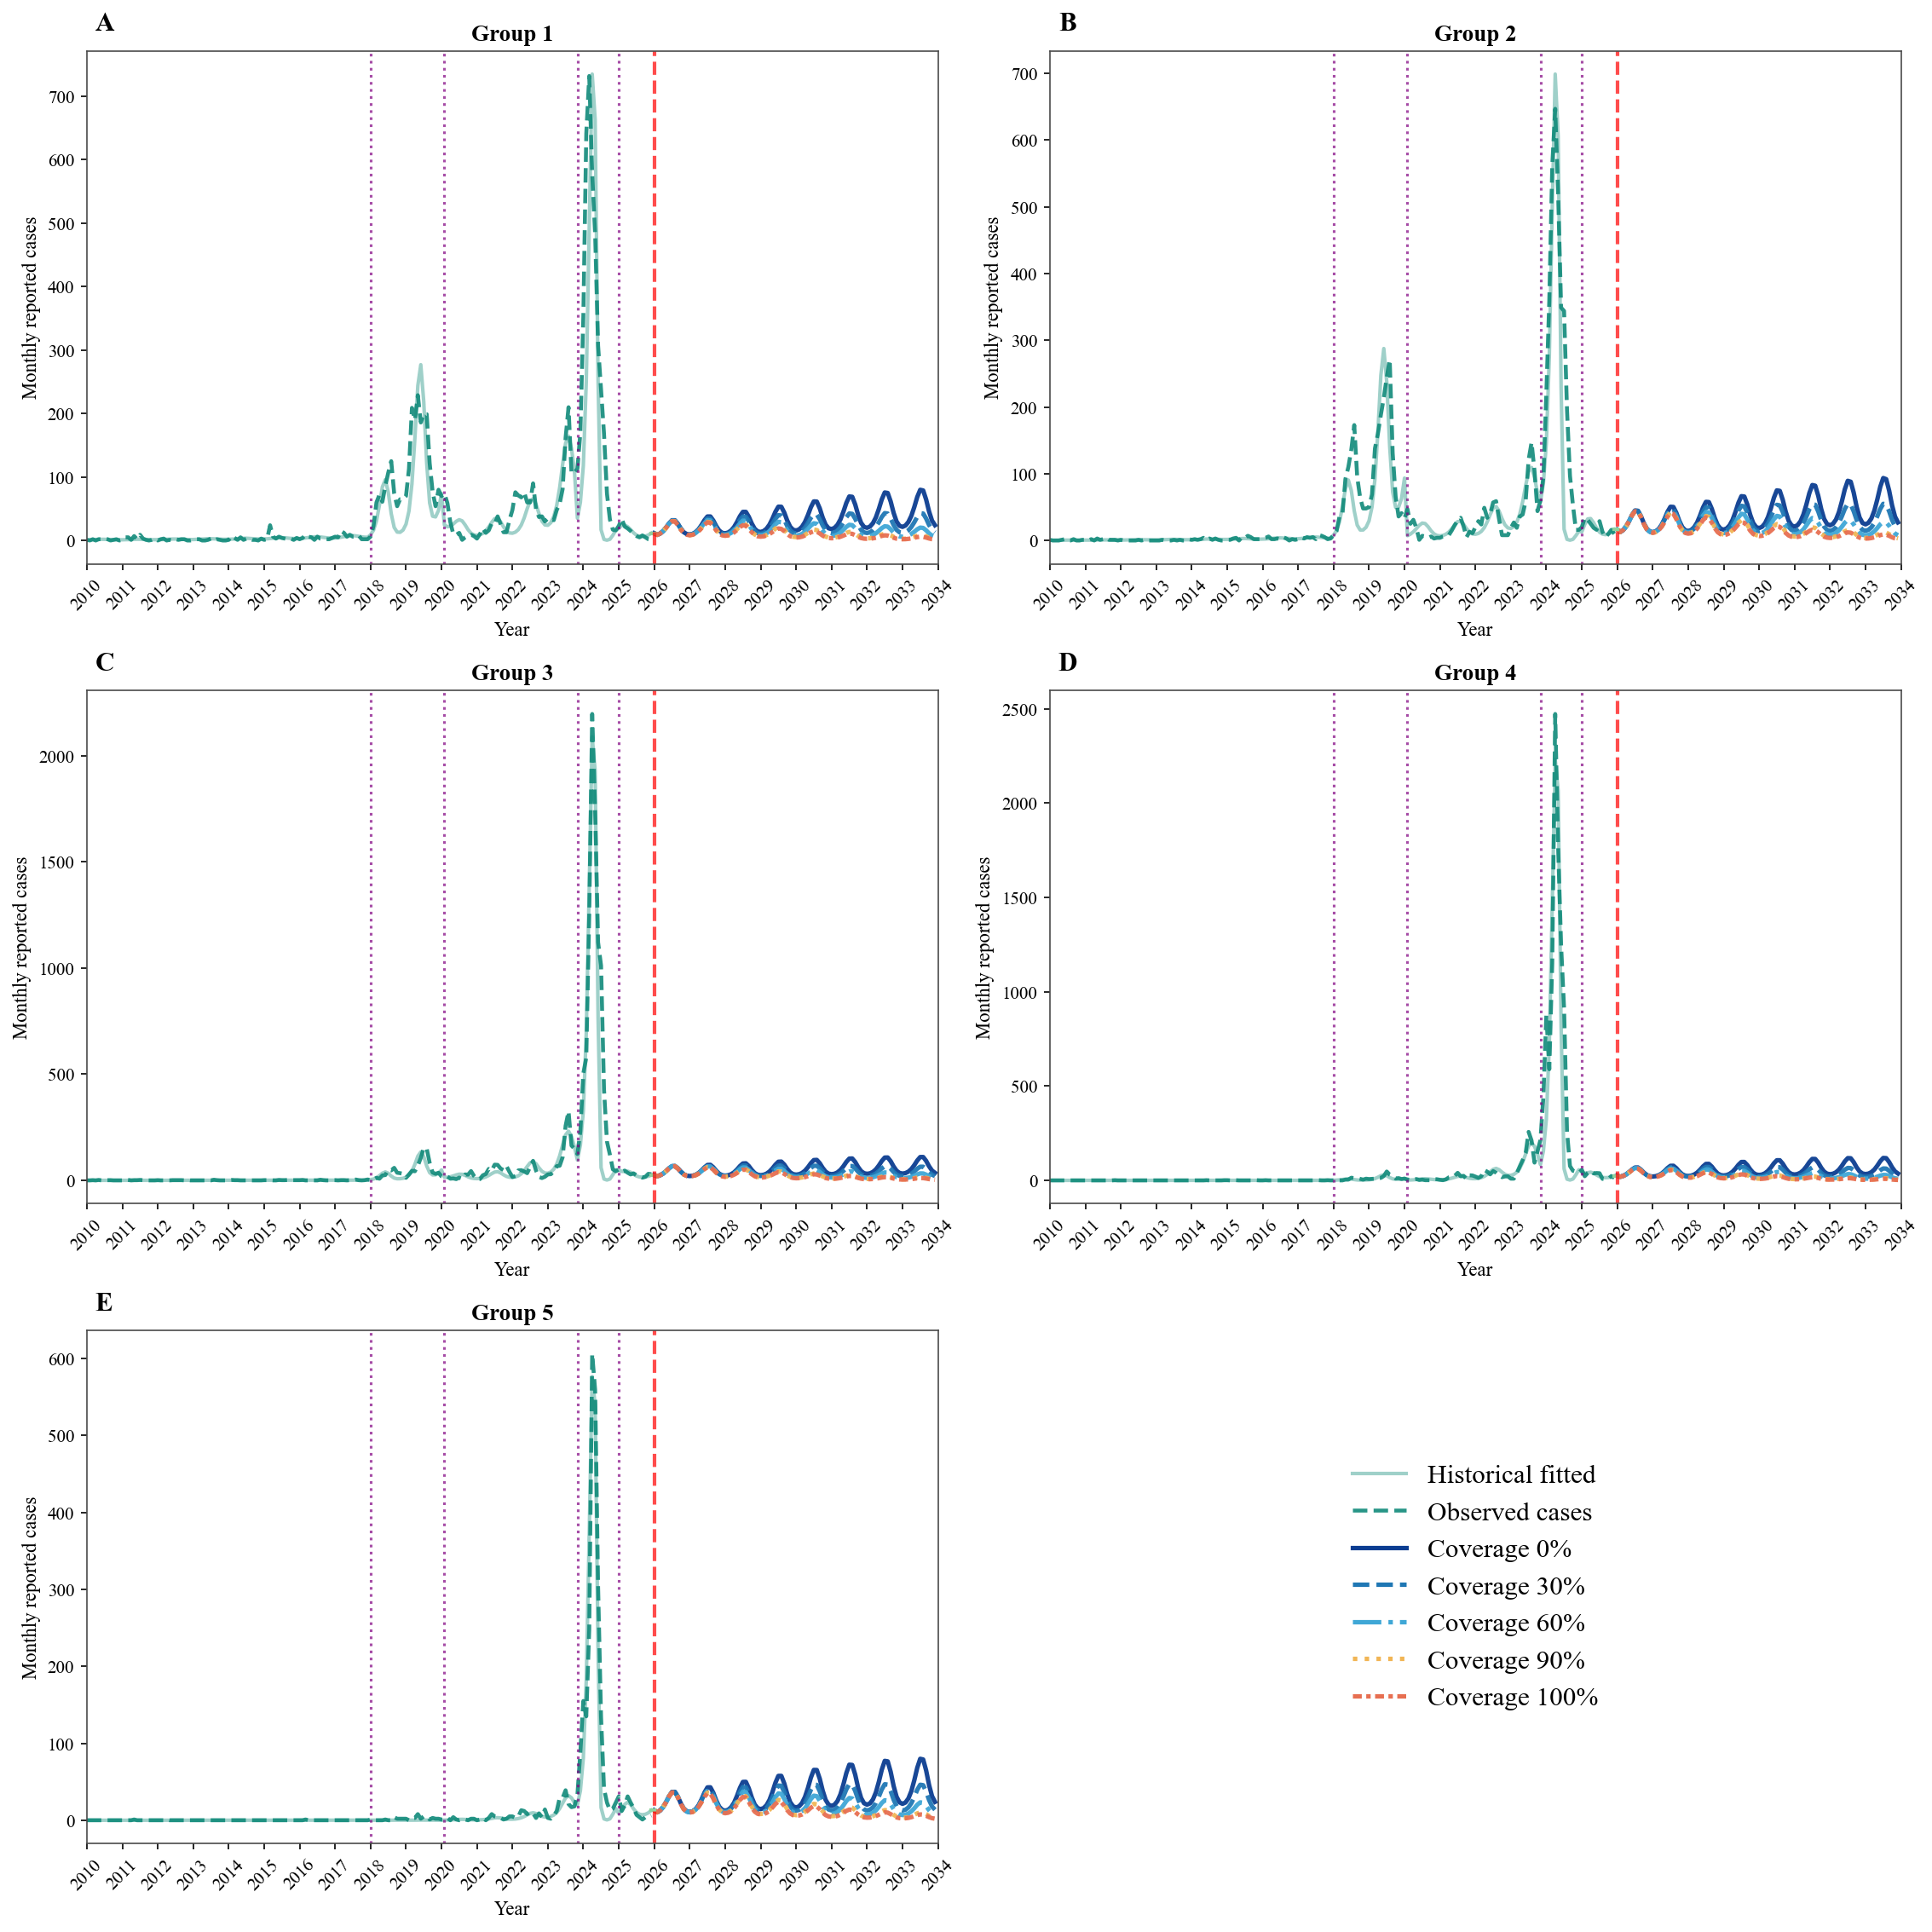


预测图表已保存到: fit_segments\prediction_vaccination_months_0192_0287\prediction_vaccination_coverage_adjusted.png


In [136]:
# 绘制预测结果
ncols = 2
nrows = math.ceil(N_GROUPS / ncols)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, 5 * nrows),
    constrained_layout=True
)
axes = axes.flatten()

seg_last_start, seg_last_end = segments[-1]
pred_start = seg_last_end
# 使用预测结果的实际长度自动确定绘图长度
sample_cov = vaccination_coverage_levels[0]
pred_len = all_predictions[sample_cov].shape[1]
pred_end = pred_start + pred_len
pred_months = np.arange(pred_start, pred_end)

target_group_idx = N_GROUPS - 1
age_palette = ['#3DAFC2', '#EB6A8A', '#108A7A', '#F49C6E', '#9B59B6', '#4E79A7']
base_age_color = age_palette[min(2, N_GROUPS-1)]
coverage_colors = ['#0B3D91', '#1F77B4', '#3FA7D6', '#F1B555', '#E76F51']
coverage_styles = ['-', '--', '-.', ':', (0, (2, 1, 1, 1))]
panel_labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

legend_handles = [
    Line2D([0], [0], color=base_age_color, linestyle='-', linewidth=2.0, alpha=0.4),
    Line2D([0], [0], color=base_age_color, linestyle='--', linewidth=2.2, alpha=0.9)
]
legend_labels = ['Historical fitted', 'Observed cases']
for idx, coverage in enumerate(vaccination_coverage_levels):
    legend_handles.append(Line2D([0], [0], color=coverage_colors[idx], linestyle=coverage_styles[idx], linewidth=2.5))
    legend_labels.append(f'Coverage {coverage_labels[idx]}')

# 准备历史拟合数据
historical_reported_data = []
for seg_idx in range(len(segments)):
    seg_start, seg_end = segments[seg_idx]
    seg_dir = OUT_DIR / f"segment_{seg_idx+1:02d}_months_{seg_start:04d}_{seg_end-1:04d}"
    if seg_dir.exists():
        seg_states = pd.read_csv(seg_dir / "states_timeseries.csv")
        seg_E = seg_states[[f"E{i}" for i in range(1, N_GROUPS+1)]].values.T
        seg_incidence = OMEGA * seg_E
        reporting_rates_path = seg_dir / "reporting_rates.csv"
        if reporting_rates_path.exists():
            reporting_rates_seg = pd.read_csv(reporting_rates_path, index_col=0).values.flatten()
        else:
            reporting_rates_seg = np.ones(N_GROUPS)
        seg_reported = reporting_rates_seg[:, None] * seg_incidence

        seg_df = pd.DataFrame(seg_reported.T, columns=[f"G{i+1}" for i in range(N_GROUPS)])
        seg_df['month'] = np.arange(seg_start, seg_end)
        historical_reported_data.append(seg_df)
        print(f"  段 {seg_idx+1}: 月份 {seg_start}-{seg_end-1}")

if historical_reported_data:
    combined_historical_df = pd.concat(historical_reported_data, ignore_index=True)
    combined_historical_df = combined_historical_df.drop_duplicates(subset=['month']).sort_values('month').reset_index(drop=True)
else:
    combined_historical_df = pd.DataFrame()

for g in range(N_GROUPS):
    ax = axes[g]

    if not combined_historical_df.empty:
        ax.plot(combined_historical_df['month'], combined_historical_df[f'G{g+1}'],
                color=base_age_color, linewidth=2.0, linestyle='-', alpha=0.4,
                label='Historical fitted')

    if seg_last_end <= inc_df.shape[0]:
        actual_months_hist = np.arange(0, seg_last_end)
        actual_data_hist = inc_df.iloc[0:seg_last_end, g].values
        ax.plot(actual_months_hist, actual_data_hist,
                label='Observed incident cases',
                color=base_age_color, linewidth=2.2, linestyle='--',
                alpha=0.9)

    for idx, coverage in enumerate(vaccination_coverage_levels):
        incidence_pred = all_predictions[coverage]
        label = f'Coverage {coverage_labels[idx]}'
        ax.plot(pred_months, incidence_pred[g, :],
                label=label,
                color=coverage_colors[idx],
                linestyle=coverage_styles[idx],
                linewidth=2.5,
                alpha=0.95)

    # 浅绿色实线连接历史拟合末点与0%预测首点
    if not combined_historical_df.empty and 0.0 in all_predictions:
        hist_last_x = seg_last_end - 1
        if hist_last_x in combined_historical_df['month'].values:
            y_hist = combined_historical_df.set_index('month').loc[hist_last_x, f'G{g+1}']
        else:
            y_hist = combined_historical_df.iloc[-1][f'G{g+1}']
        y_pred0 = all_predictions[0.0][g, 0]
        ax.plot([hist_last_x, pred_start], [y_hist, y_pred0],
                color='#8FD19E', linewidth=2.0, linestyle='-')

    if pred_start < inc_df.shape[0]:
        actual_end = min(pred_end, inc_df.shape[0])
        if actual_end > pred_start:
            actual_months = np.arange(pred_start, actual_end)
            actual_data = inc_df.iloc[pred_start:actual_end, g].values
            ax.plot(actual_months, actual_data,
                    label='Actual',
                    color=age_palette[g], linewidth=2.0, linestyle=':',
                    alpha=0.9)

    ax.set_title(f'Group {g+1}', 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Monthly reported cases', fontsize=11)
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_color('#4A4A4A')
        spine.set_linewidth(0.8)
    ax.text(0.01, 1.04, panel_labels[g], transform=ax.transAxes,
            fontsize=15, fontweight='bold')

    # 年度刻度：2010年起，每12个月标一刻度
    ticks = np.arange(0, pred_end + 1, 12)
    tick_labels = [2010 + int(x/12) for x in ticks]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, rotation=45)

    for boundary in segments[:-1]:
        ax.axvline(x=boundary[1], color='purple', linestyle=':', linewidth=1.5, alpha=0.7)

    ax.axvline(x=pred_start, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.set_xlim(0, pred_end)

extra_axes = axes[N_GROUPS:]
if extra_axes:
    legend_ax = extra_axes[0]
    legend_ax.axis('off')
    legend_ax.legend(legend_handles, legend_labels, loc='center', frameon=False, fontsize=15)
for ax in extra_axes[1:]:
    ax.axis('off')
if not extra_axes:
    fig.legend(legend_handles, legend_labels, loc='lower right', frameon=False, fontsize=10)

pred_dir_vax = OUT_DIR / f"prediction_vaccination_months_{pred_start:04d}_{pred_end-1:04d}"
pred_dir_vax.mkdir(exist_ok=True)
plt.savefig(pred_dir_vax / "prediction_vaccination_coverage_adjusted.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n预测图表已保存到: {pred_dir_vax / 'prediction_vaccination_coverage_adjusted.png'}")

In [137]:
# 计算各组以及总体（五组合计）的 R²
print("="*60)
print("计算各组及总体 R²")
print("="*60)

if not combined_historical_df.empty and seg_last_end <= inc_df.shape[0]:
    fitted_months = combined_historical_df['month'].values
    actual_months = np.arange(0, seg_last_end)
    common_months = np.intersect1d(fitted_months, actual_months)

    if len(common_months) == 0:
        print("无共同月份，无法计算 R²")
    else:
        fitted_common = combined_historical_df.set_index('month').loc[common_months]
        actual_common = inc_df.iloc[common_months, :].values  # shape (T, G)

        r2_per_group = []
        print("各组 R²：")
        for g in range(N_GROUPS):
            y_obs = actual_common[:, g]
            y_pred = fitted_common[f'G{g+1}'].values
            mask = np.isfinite(y_obs) & np.isfinite(y_pred)
            y_obs, y_pred = y_obs[mask], y_pred[mask]
            if len(y_obs) < 2:
                r2 = np.nan
            else:
                ss_res = np.sum((y_obs - y_pred) ** 2)
                ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
                r2 = np.nan if ss_tot <= 0 else 1 - ss_res / ss_tot
            r2_per_group.append(r2)
            print(f"  Group {g+1}: R² = {r2:.4f}" if not np.isnan(r2) else f"  Group {g+1}: R² = NaN")

        # 总体（五组合计）
        y_obs_total = actual_common.sum(axis=1)
        y_pred_total = fitted_common[[f'G{i+1}' for i in range(N_GROUPS)]].values.sum(axis=1)
        mask_total = np.isfinite(y_obs_total) & np.isfinite(y_pred_total)
        y_obs_total, y_pred_total = y_obs_total[mask_total], y_pred_total[mask_total]
        if len(y_obs_total) >= 2:
            ss_res_tot = np.sum((y_obs_total - y_pred_total) ** 2)
            ss_tot_tot = np.sum((y_obs_total - np.mean(y_obs_total)) ** 2)
            r2_total = np.nan if ss_tot_tot <= 0 else 1 - ss_res_tot / ss_tot_tot
        else:
            r2_total = np.nan
        print(f"总体（五组合计）R² = {r2_total:.4f}" if not np.isnan(r2_total) else "总体（五组合计）R² = NaN")
else:
    print("历史拟合或观测数据不足，无法计算 R²")
# 计算各覆盖度下的疫苗有效率（相对于 0% 覆盖）
print("="*60)
print("各覆盖度疫苗有效率（相对 0% 覆盖）")
print("="*60)

if 0.0 not in all_predictions:
    print("缺少 0% 覆盖预测结果，无法计算有效率。")
else:
    baseline = all_predictions[0.0]
    total_baseline = baseline.sum()
    for cov in vaccination_coverage_levels:
        pred_cov = all_predictions.get(cov)
        if pred_cov is None:
            print(f"覆盖率 {cov*100:.0f}% 缺少预测结果，跳过。")
            continue
        total_cov = pred_cov.sum()
        ve_total = np.nan if total_baseline <= 0 else 1 - total_cov / total_baseline
        ve_groups = []
        for g in range(N_GROUPS):
            base_g = baseline[g].sum()
            cov_g = pred_cov[g].sum()
            ve_g = np.nan if base_g <= 0 else 1 - cov_g / base_g
            ve_groups.append(ve_g)
        ve_groups_str = ", ".join(
            [f"G{i+1}:{v:.4f}" if np.isfinite(v) else f"G{i+1}:NaN" for i, v in enumerate(ve_groups)]
        )
        if np.isfinite(ve_total):
            print(f"覆盖率 {cov*100:.0f}% 总体有效率: {ve_total:.4f}")
        else:
            print(f"覆盖率 {cov*100:.0f}% 总体有效率: NaN")
        print(f"  分年龄组有效率: {ve_groups_str}")



计算各组及总体 R²
各组 R²：
  Group 1: R² = 0.7397
  Group 2: R² = 0.8310
  Group 3: R² = 0.8813
  Group 4: R² = 0.8785
  Group 5: R² = 0.9389
总体（五组合计）R² = 0.8944
各覆盖度疫苗有效率（相对 0% 覆盖）
覆盖率 0% 总体有效率: 0.0000
  分年龄组有效率: G1:0.0000, G2:0.0000, G3:0.0000, G4:0.0000, G5:0.0000
覆盖率 30% 总体有效率: 0.2771
  分年龄组有效率: G1:0.3066, G2:0.2633, G3:0.2477, G4:0.3032, G5:0.2675
覆盖率 60% 总体有效率: 0.4753
  分年龄组有效率: G1:0.5169, G2:0.4597, G3:0.4314, G4:0.5104, G5:0.4635
覆盖率 90% 总体有效率: 0.6078
  分年龄组有效率: G1:0.6524, G2:0.5946, G3:0.5587, G4:0.6440, G5:0.5968
覆盖率 100% 总体有效率: 0.6407
  分年龄组有效率: G1:0.6852, G2:0.6284, G3:0.5910, G4:0.6765, G5:0.6301


生成年度汇总图（五个年龄组总和）


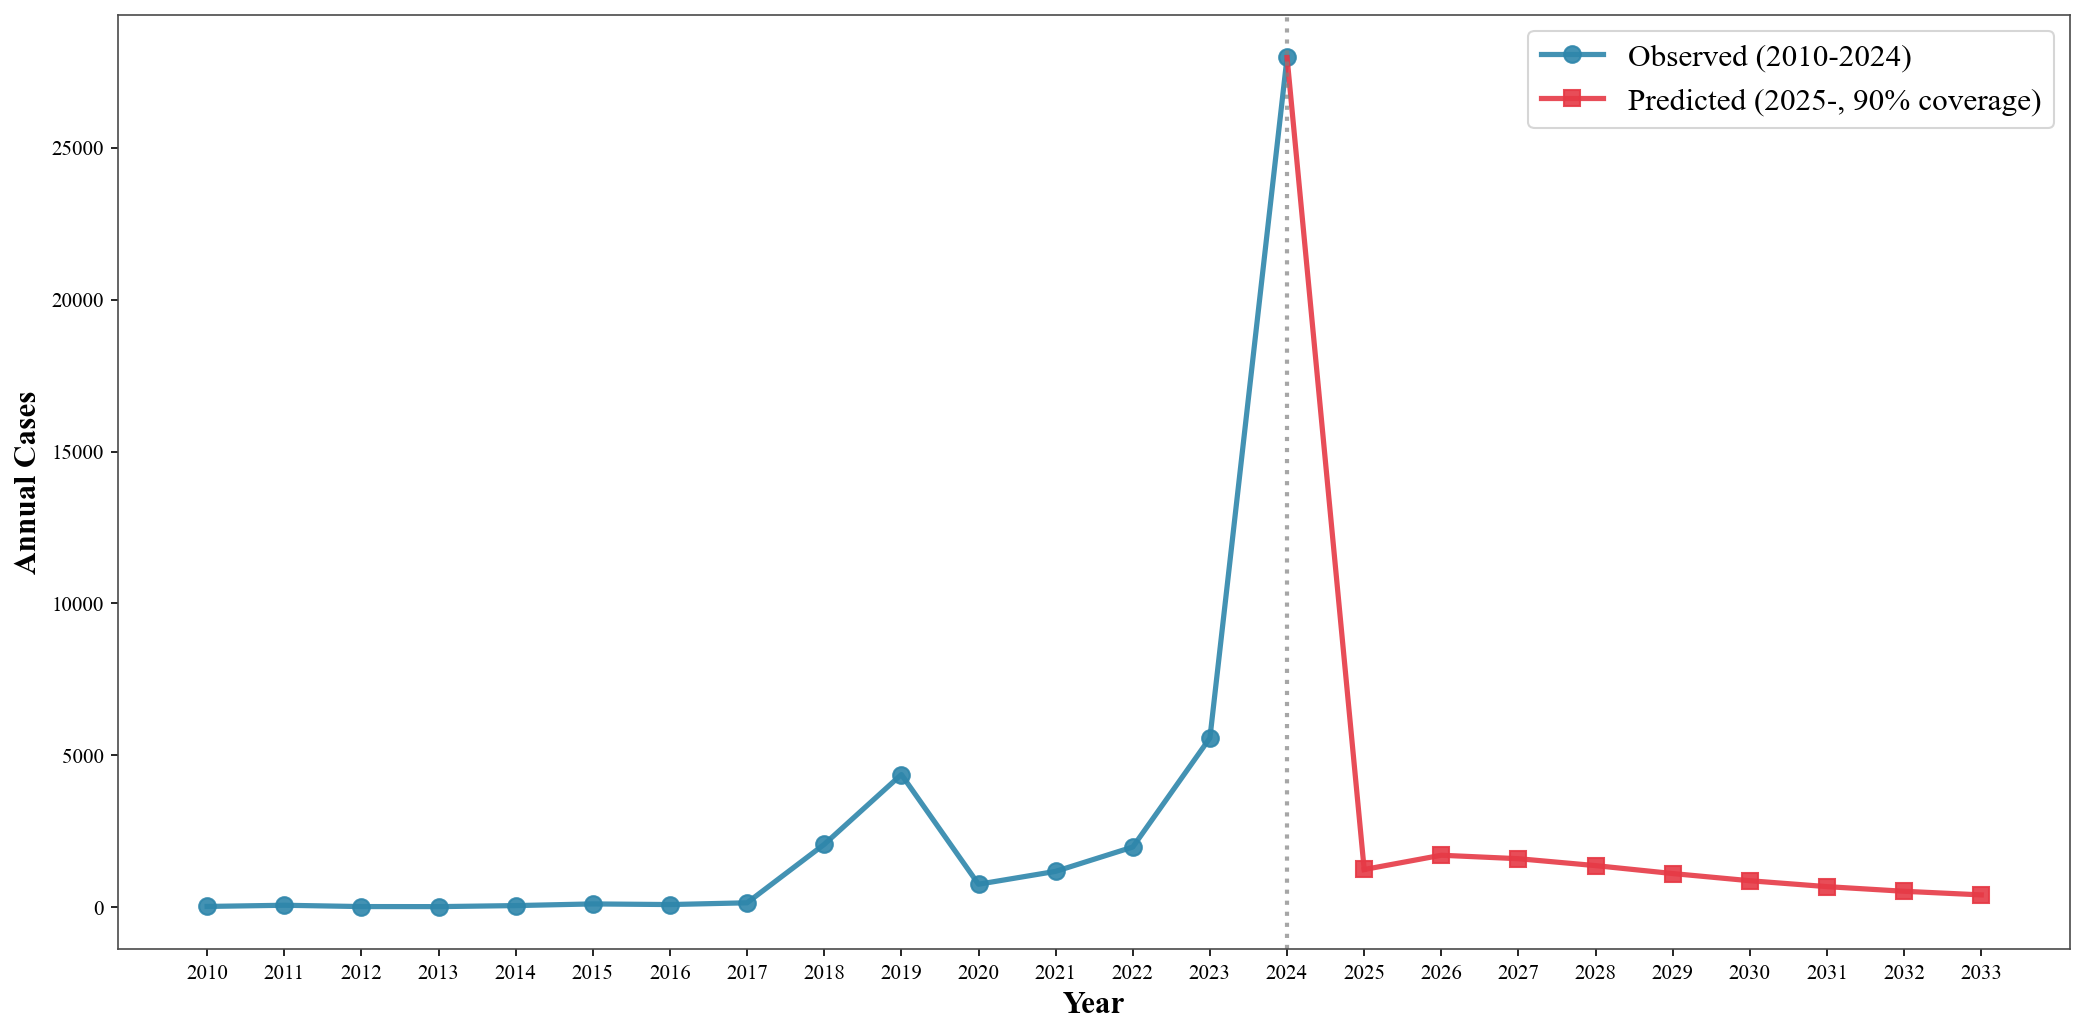


年度汇总图已保存到: fit_segments\prediction_vaccination_months_0192_0287\annual_summary_total_cases.png
年度汇总统计（五个年龄组总和）

观测期 (2010-2024):
  2010: 28 例
  2011: 67 例
  2012: 24 例
  2013: 22 例
  2014: 56 例
  2015: 111 例
  2016: 90 例
  2017: 148 例
  2018: 2072 例
  2019: 4370 例
  2020: 759 例
  2021: 1183 例
  2022: 1983 例
  2023: 5573 例
  2024: 27973 例
预测期 (2025-, 90% coverage):
  2025: 1244 例
  2026: 1713 例
  2027: 1599 例
  2028: 1372 例
  2029: 1111 例
  2030: 874 例
  2031: 680 例
  2032: 527 例
  2033: 408 例

观测期平均年发病数: 2964 例
观测期总发病数: 44459 例

预测期平均年发病数 (90% coverage): 1059 例
预测期总发病数 (90% coverage): 9528 例


In [138]:
# 年度汇总图：观测值（2024年以前）+ 预测值（2025年开始）
print("="*60)
print("生成年度汇总图（五个年龄组总和）")
print("="*60)

# 历史观测数据（2024年以前，即月份0-179）
obs_end_month = seg_last_end  # 180，对应2024年12月
obs_data = inc_df.iloc[0:obs_end_month, :].values  # (180, 5)
obs_total = obs_data.sum(axis=1)  # 每月五个年龄组总和

# 预测数据（从2025年开始，使用90%覆盖率）
pred_data = all_predictions[0.9]  # (5, 48) - 5个年龄组，48个月预测
pred_total = pred_data.sum(axis=0)  # 每月五个年龄组总和

# 合并观测和预测数据
all_months = np.arange(0, obs_end_month + len(pred_total))
all_total = np.concatenate([obs_total, pred_total])

# 按年汇总
# 确定年份范围
start_year = 2010
end_year = start_year + (len(all_total) - 1) // 12

yearly_totals = []
yearly_labels = []
yearly_types = []  # 'observed' 或 'predicted'

for year in range(start_year, end_year + 1):
    year_start_month = (year - start_year) * 12
    year_end_month = min(year_start_month + 12, len(all_total))
    
    if year_end_month > year_start_month:
        year_data = all_total[year_start_month:year_end_month]
        yearly_total = year_data.sum()
        yearly_totals.append(yearly_total)
        yearly_labels.append(year)
        
        # 判断是观测值还是预测值
        if year < 2025:
            yearly_types.append('observed')
        else:
            yearly_types.append('predicted')

yearly_totals = np.array(yearly_totals)
yearly_labels = np.array(yearly_labels)

# 绘制图表
fig, ax = plt.subplots(figsize=(14, 7))

# 分离观测值和预测值
obs_mask = np.array([t == 'observed' for t in yearly_types])
pred_mask = np.array([t == 'predicted' for t in yearly_types])

obs_years = yearly_labels[obs_mask]
obs_values = yearly_totals[obs_mask]
pred_years = yearly_labels[pred_mask]
pred_values = yearly_totals[pred_mask]

# 绘制观测值
if len(obs_years) > 0:
    ax.plot(obs_years, obs_values, 'o-', color='#2E86AB', linewidth=2.5, 
            markersize=8, label='Observed (2010-2024)', alpha=0.9)

# 绘制预测值（红线连接）
if len(pred_years) > 0:
    ax.plot(pred_years, pred_values, 's-', color='#E63946', linewidth=2.5,
            markersize=8, label='Predicted (2025-, 90% coverage)', alpha=0.9)

    # 用红色线将2024年末与2025年首个预测点连接
    if len(obs_years) > 0:
        ax.plot([obs_years[-1], pred_years[0]],
                [obs_values[-1], pred_values[0]],
                color='#E63946', linewidth=2.5, alpha=0.9, linestyle='-')

# 添加分界线（与2024对齐）
ax.axvline(x=2024, color='gray', linestyle=':', linewidth=2, alpha=0.7)

# 设置图表样式
ax.set_xlabel('Year', fontsize=15, fontweight='bold')
ax.set_ylabel('Annual Cases', fontsize=15, fontweight='bold')
ax.legend(fontsize=15)

# 设置x轴刻度（年份对齐，不倾斜）

ax.set_xticks(yearly_labels)
ax.set_xticklabels(yearly_labels)


# 添加数值标签（可选，如果数据点不太多）
# if len(yearly_labels) <= 20:
#     for year, value, typ in zip(yearly_labels, yearly_totals, yearly_types):
#         if typ == 'observed':
#             ax.annotate(f'{value:.0f}', (year, value), 
#                        textcoords="offset points", xytext=(0,10), 
#                        ha='center', fontsize=9, alpha=0.7)
#         else:
#             ax.annotate(f'{value:.0f}', (year, value), 
#                        textcoords="offset points", xytext=(0,-15), 
#                        ha='center', fontsize=9, alpha=0.7, color='#E63946')

ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_color('#4A4A4A')
    spine.set_linewidth(0.8)

plt.tight_layout()

# 保存图片
summary_fig_path = pred_dir_vax / "annual_summary_total_cases.png"
plt.savefig(summary_fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n年度汇总图已保存到: {summary_fig_path}")

# 打印汇总统计

print("年度汇总统计（五个年龄组总和）")
print(f"\n观测期 (2010-2024):")
for year, value, typ in zip(yearly_labels, yearly_totals, yearly_types):
    if typ == 'observed':
        print(f"  {year}: {value:.0f} 例")

print(f"预测期 (2025-, 90% coverage):")
for year, value, typ in zip(yearly_labels, yearly_totals, yearly_types):
    if typ == 'predicted':
        print(f"  {year}: {value:.0f} 例")

if len(obs_values) > 0:
    print(f"\n观测期平均年发病数: {obs_values.mean():.0f} 例")
    print(f"观测期总发病数: {obs_values.sum():.0f} 例")

if len(pred_values) > 0:
    print(f"\n预测期平均年发病数 (90% coverage): {pred_values.mean():.0f} 例")
    print(f"预测期总发病数 (90% coverage): {pred_values.sum():.0f} 例")


segment_01_months_0000_0095: Reff = 1.0576
segment_02_months_0095_0120: Reff = 1.2062
segment_03_months_0120_0165: Reff = 0.9895
segment_04_months_0165_0179: Reff = 0.7949
segment_05_months_0179_0191: Reff = 0.9295
Reff 矩阵已保存到: fit_segments\Reff_matrices.xlsx


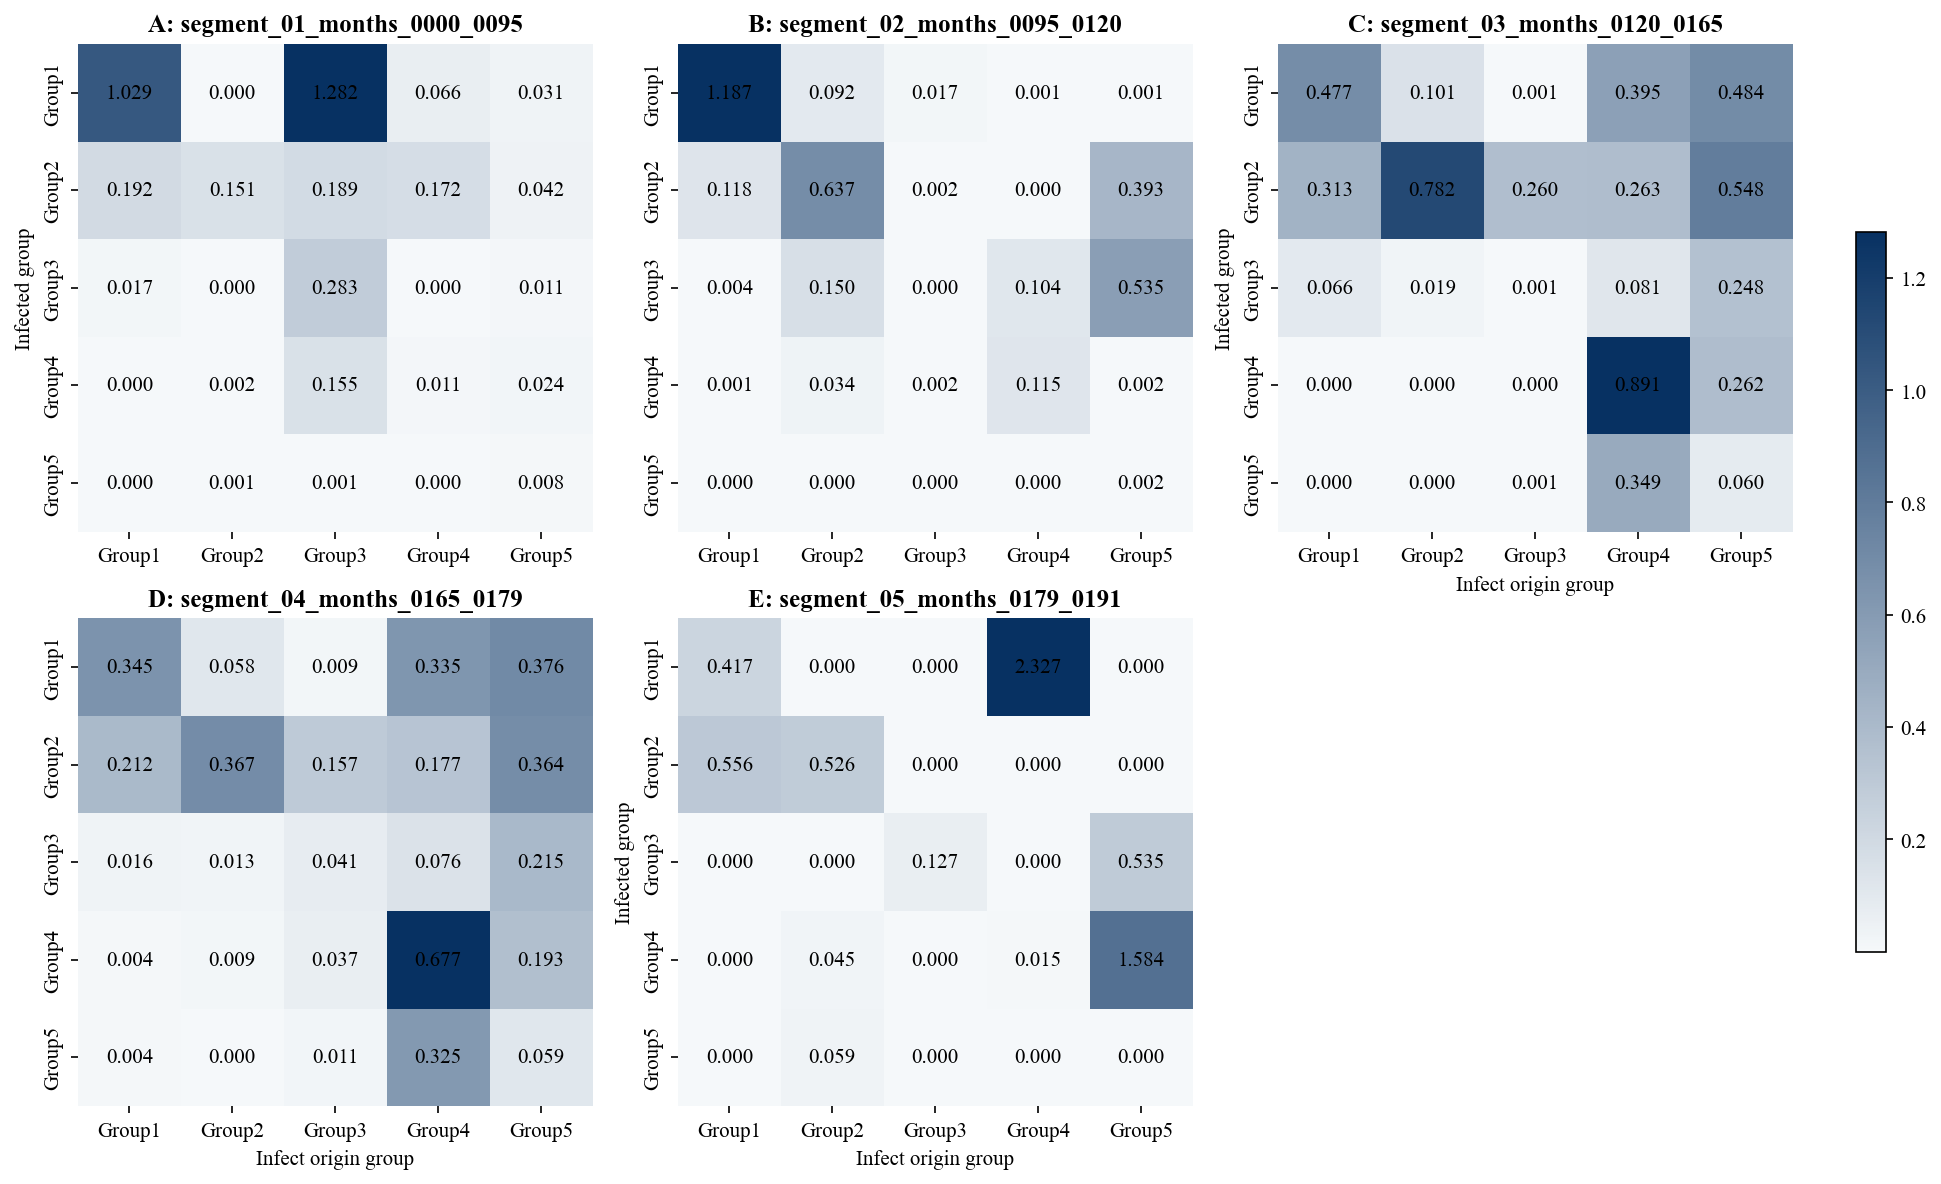

各分段热图已保存到: fit_segments\Reff_heatmaps_per_segment.png


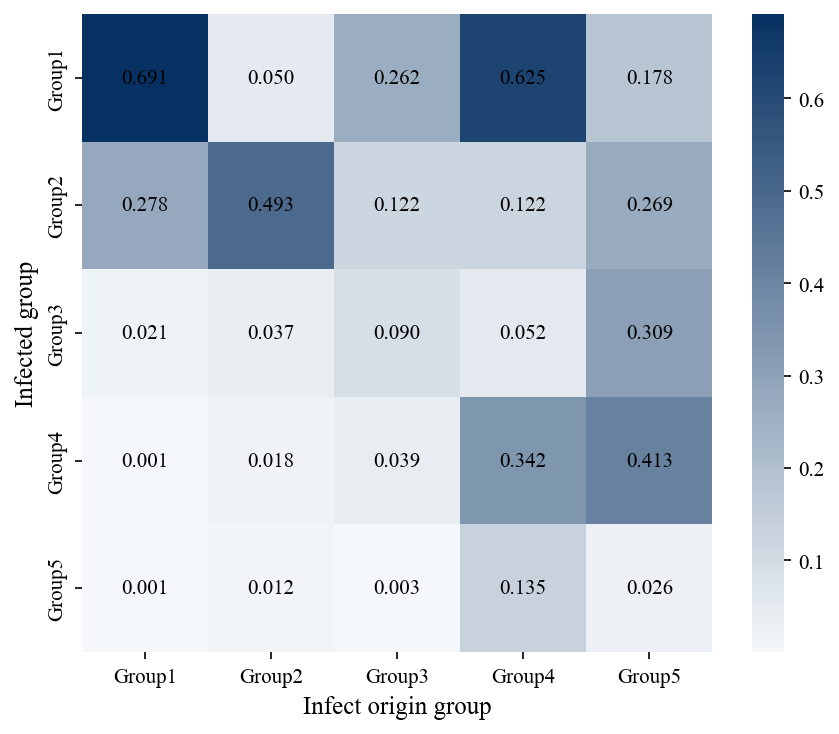

组合热图已保存到: fit_segments\Reff_heatmap_mean.png


In [139]:
# 计算各分段的 Reff 矩阵并保存为 Excel
from matplotlib.colors import LinearSegmentedColormap
cmap_br = LinearSegmentedColormap.from_list("blue_red", ["#0000FF", "#FF0000"])

D_INF = 1.0 / GAMMA  # 感染期平均时长

def load_state_vector(path: Path):
    # final_state.csv 第一列为数值
    return pd.read_csv(path, index_col=0).iloc[:, 0].values

seg_root = Path("fit_segments")
segment_dirs = sorted([p for p in seg_root.iterdir() if p.is_dir() and p.name.startswith("segment")])

if len(segment_dirs) == 0:
    print("未找到分段目录，跳过计算")
else:
    reff_summary = []
    reff_mats = []  # 收集各段 Reff 矩阵用于可视化
    out_path = seg_root / "Reff_matrices.xlsx"
    with pd.ExcelWriter(out_path, engine='openpyxl') as writer:
        for seg in segment_dirs:
            beta_path = seg / "beta_matrix.csv"
            state_path = seg / "final_state.csv"
            if (not beta_path.exists()) or (not state_path.exists()):
                print(f"跳过 {seg.name}：缺少 beta_matrix 或 final_state")
                continue
            beta = pd.read_csv(beta_path, index_col=0).values
            y_end = load_state_vector(state_path)
            n = N_GROUPS
            # 状态顺序 V,S,E,I,R 各 n 个
            V = y_end[0:n]
            S = y_end[n:2*n]
            E = y_end[2*n:3*n]
            I = y_end[3*n:4*n]
            R = y_end[4*n:5*n]
            N_pop = V + S + E + I + R
            # 避免除零
            safe_den = np.where(N_pop <= 0, 1.0, N_pop)
            # 下一代矩阵 K
            K = beta * D_INF * (S / safe_den).reshape(-1, 1)
            eigvals = np.linalg.eigvals(K)
            Reff_all = float(np.max(np.real(eigvals)))
            df_K = pd.DataFrame(K, index=[f"G{i+1}" for i in range(n)], columns=[f"G{i+1}" for i in range(n)])
            df_K.to_excel(writer, sheet_name=seg.name)
            reff_summary.append({"segment": seg.name, "Reff": Reff_all})
            reff_mats.append((seg.name, K))
            print(f"{seg.name}: Reff = {Reff_all:.4f}")
        if len(reff_summary) > 0:
            pd.DataFrame(reff_summary).to_excel(writer, sheet_name="summary", index=False)
    if len(reff_summary) > 0:
        print(f"Reff 矩阵已保存到: {out_path}")
    else:
        print("无可保存的 Reff 结果")

    # 每个分段单独热图 + 组合均值热图
    if len(reff_mats) > 0:
        seg_names = [m[0] for m in reff_mats]
        Ks = np.stack([m[1] for m in reff_mats], axis=0)  # (segments, n, n)
        K_mean = Ks.mean(axis=0)
        from matplotlib.colors import LinearSegmentedColormap
        cmap_reff = LinearSegmentedColormap.from_list("ReffBlue", ["#F5F8FA", "#073162"])

        # 每段热图网格
        n_seg = len(seg_names)
        ncols = 2 if n_seg <= 4 else 3
        nrows = int(np.ceil(n_seg / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
        axes = np.array(axes).reshape(-1)
        letters = ["A", "B", "C", "D", "E", "F", "G", "H"]
        colorbar_mappable = None
        for idx, (name, Kmat) in enumerate(reff_mats):
            ax = axes[idx]
            dfK = pd.DataFrame(Kmat, index=[f"Group{i+1}" for i in range(n)], columns=[f"Group{i+1}" for i in range(n)])
            try:
                import seaborn as sns
                hm = sns.heatmap(
                    dfK,
                    annot=True,
                    fmt=".3f",
                    cmap=cmap_reff,
                    cbar=False,
                    ax=ax,
                    annot_kws={"color": "black"},
                )
                if colorbar_mappable is None:
                    colorbar_mappable = hm.collections[0]
            except Exception:
                im = ax.imshow(Kmat, cmap=cmap_reff)
                if colorbar_mappable is None:
                    colorbar_mappable = im
                for i in range(n):
                    for j in range(n):
                        ax.text(j, i, f"{Kmat[i,j]:.2f}", ha="center", va="center", color="black")
            prefix = letters[idx] if idx < len(letters) else chr(ord('A') + idx)
            ax.set_title(f"{prefix}: {name}", fontsize=12, fontweight='bold')
            if idx not in (0, 1):
                ax.set_xlabel("Infect origin group", fontsize=10)
            else:
                ax.set_xlabel("")
            if idx not in (1, 3):
                ax.set_ylabel("Infected group", fontsize=10)
            else:
                ax.set_ylabel("")
        # 隐藏多余子图
        for j in range(n_seg, len(axes)):
            axes[j].axis('off')
        # 统一右侧色标（放在图外，不与子图重叠）
        if colorbar_mappable is not None:
            plt.tight_layout(rect=[0, 0, 0.9, 1])
            cax = fig.add_axes([0.92, 0.2, 0.015, 0.6])  # [left, bottom, width, height]
            fig.colorbar(colorbar_mappable, cax=cax)
        else:
            plt.tight_layout()
        per_seg_path = seg_root / "Reff_heatmaps_per_segment.png"
        plt.savefig(per_seg_path, dpi=200, bbox_inches='tight')
        plt.show()
        print(f"各分段热图已保存到: {per_seg_path}")

        # 均值热图
        df_mean = pd.DataFrame(K_mean, index=[f"Group{i+1}" for i in range(n)], columns=[f"Group{i+1}" for i in range(n)])
        plt.figure(figsize=(6, 5))
        try:
            import seaborn as sns
            sns.heatmap(
                df_mean,
                annot=True,
                fmt=".3f",
                cmap=cmap_reff,
                annot_kws={"color": "black"},
            )
        except Exception:
            plt.imshow(K_mean, cmap=cmap_reff)
            plt.colorbar()
            for i in range(n):
                for j in range(n):
                    plt.text(j, i, f"{K_mean[i,j]:.2f}", ha="center", va="center", color="black")
            plt.xticks(range(n), df_mean.columns)
            plt.yticks(range(n), df_mean.index)
        plt.xlabel("Infect origin group", fontsize=12)
        plt.ylabel("Infected group", fontsize=12)
        plt.tight_layout()
        heatmap_path = seg_root / "Reff_heatmap_mean.png"
        plt.savefig(heatmap_path, dpi=200, bbox_inches='tight')
        plt.show()
        print(f"组合热图已保存到: {heatmap_path}")

